# Exploratory Data Analysis - EDA


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import apply_balance, plot_top_ngrams, save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


load train dataset

In [3]:
sample_train = pd.read_csv(r'data/samples/sample_train.csv', dtype=str, quoting=0)
sample_train.head()

,review_target,review_title,review_content
0,2,"Good tool, good price",I received the tool in a timely fashion.Assemb...
1,1,Not what I expected!,"This toy has alot of activities, but is not a ..."
2,1,Not so great,"I wanted this hair wax for a while, and once I..."
3,1,"Great hardware, but the PC software is terrible",The hardware functionality is excellent for ou...
4,2,A must for anyone who cooks and bakes!!!,To say that i am pleased with my kitchenaid ar...


In [4]:
sample_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   review_target   80000 non-null  str  
 1   review_title    79994 non-null  str  
 2   review_content  80000 non-null  str  
dtypes: str(3)
memory usage: 1.8 MB


In [5]:
print('There are {} rows and {} columns in train'.format(sample_train.shape[0], sample_train.shape[1]))

There are 80000 rows and 3 columns in train


In [6]:
sample_train.describe()

,review_target,review_title,review_content
count,80000,79994,80000
unique,2,70353,79998
top,1,Disappointed,There are few today who do not know the name M...
freq,40010,222,2


Check Missing Values


In [7]:
sample_train.isna().sum()

review_target     0
review_title      6
review_content    0
dtype: int64

In [8]:
sample_train.dropna(inplace=True)
sample_train.isna().sum()

review_target     0
review_title      0
review_content    0
dtype: int64

check duplications

In [9]:
sample_train.duplicated().sum()

np.int64(0)

Check Class Balance

In [10]:
sample_train.value_counts('review_target')

review_target
1    40008
2    39986
Name: count, dtype: int64

In [11]:
sample_train.groupby('review_target').describe()


review_title                           review_content         \
                     count unique           top freq          count unique   
review_target                                                                
1                    40008  34830  Disappointed  221          40008  40007   
2                    39986  35746     Excellent   98          39986  39985   

                                                                       
                                                             top freq  
review_target                                                          
1              I am aware of the difference between the Dept ...    2  
2              There are few today who do not know the name M...    2

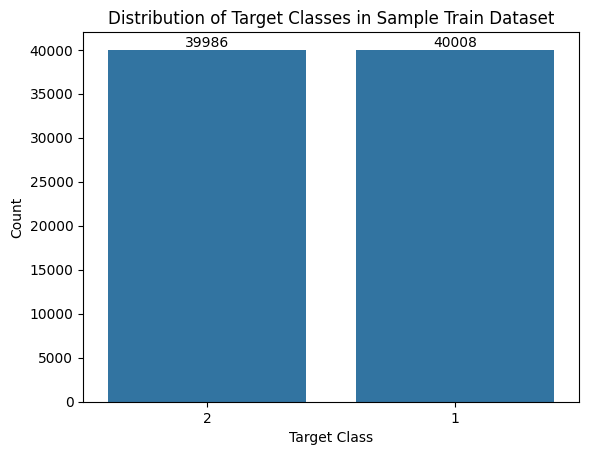

In [12]:
ax= sns.countplot(x='review_target', data=sample_train)
for p in ax.patches: # bars
    '''
    get_bbox(): return bounding box of the bar, 
    get_points(): returns the coordinates of the four corners of the bounding box.
    '''
    x= p.get_bbox().get_points()[:,0]
    y= p.get_bbox().get_points()[1,1] 
    ax.annotate(f'{y:.0f}', (x.mean(), y), ha='center',va='bottom')
plt.title('Distribution of Target Classes in Sample Train Dataset')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

## Original Class Distribution

The original training sample shows an imbalance between positive (1) and negative (2) reviews. This imbalance could lead to biased models that perform poorly on the minority class. Balancing the dataset is crucial for fair sentiment classification.

label distribution

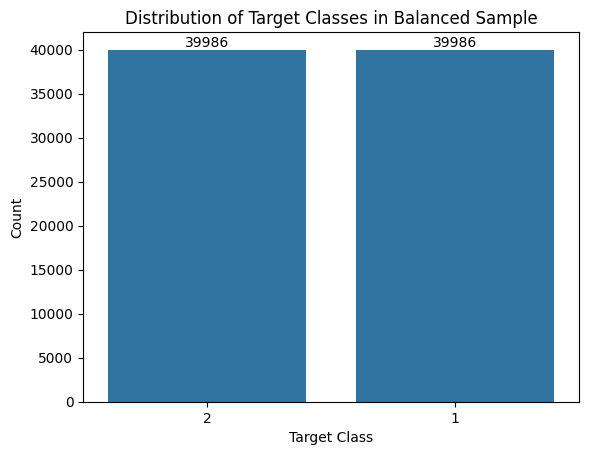

In [13]:
balanced_sample_train = apply_balance(sample_train, target_col='review_target', random_state=42)

ax= sns.countplot(x='review_target', data=balanced_sample_train)
for p in ax.patches:
    '''
    get_bbox(): return bounding box of the bar, 
    get_points(): returns the coordinates of the four corners of the bounding box.
    '''
    x= p.get_bbox().get_points()[:,0]
    y= p.get_bbox().get_points()[1,1] 
    ax.annotate(f'{y:.0f}', (x.mean(), y), ha='center',va='bottom')
plt.title('Distribution of Target Classes in Balanced Sample')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

## Balanced Class Distribution

After applying balancing techniques, the dataset now has equal representation of positive and negative reviews. This balanced approach ensures the model learns equally from both classes, improving overall accuracy and reducing bias in sentiment predictions.

In [14]:
# balanced_sample_train.value_counts('review_target')

Text Analysis by char and word counts

In [15]:
balanced_sample_train['review_content_char_count'] = balanced_sample_train['review_content'].str.len()
balanced_sample_train.head()

,review_target,review_title,review_content,review_content_char_count
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586
1,1,not so great,I'm using this book in an introductory organic...,570
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198


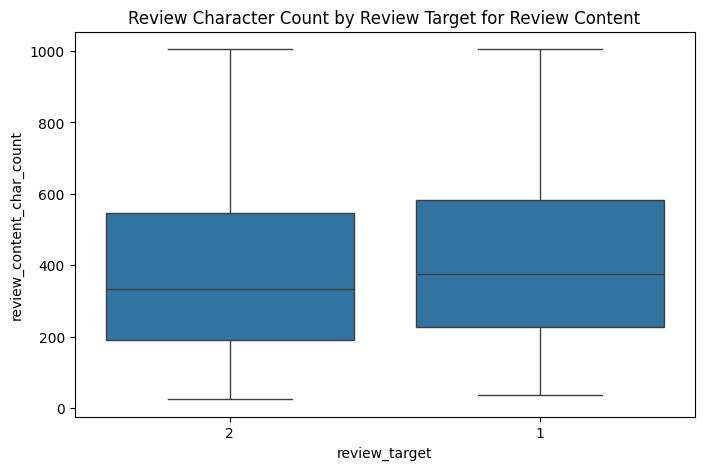

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='review_target', y='review_content_char_count', data=balanced_sample_train)
plt.title('Review Character Count by Review Target for Review Content')
plt.show()

## Character Count by Sentiment

The boxplot shows that negative reviews tend to have slightly longer character counts than positive ones. This suggests that dissatisfied customers might provide more detailed feedback. Character count could be a useful feature for sentiment classification.

In [17]:
balanced_sample_train['review_content_word_count'] = balanced_sample_train['review_content'].apply(lambda x: len(str(x).split()))
balanced_sample_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108
1,1,not so great,I'm using this book in an introductory organic...,570,88
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38


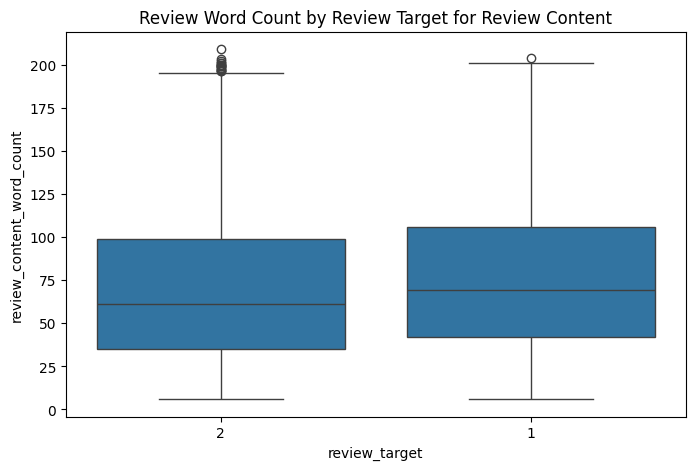

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='review_target', y='review_content_word_count', data=balanced_sample_train)
plt.title('Review Word Count by Review Target for Review Content')
plt.show()

## Word Count by Sentiment

Similar to character count, negative reviews show higher word counts on average. This pattern indicates that customers expressing dissatisfaction often elaborate more in their reviews, providing richer textual data for analysis.

apply describe on two numerical cols

In [19]:
balanced_sample_train[['review_content_char_count','review_content_word_count']].describe().T

,count,mean,std,min,25%,50%,75%,max
review_content_char_count,79972.0,404.347584,234.072075,25.0,207.0,354.0,564.0,1005.0
review_content_word_count,79972.0,74.022608,42.263353,6.0,38.0,65.0,103.0,209.0


In [20]:
print("Average characters per review:", balanced_sample_train['review_content_char_count'].mean())
print("Average words per review:", balanced_sample_train['review_content_word_count'].mean())

Average characters per review: 404.34758415445407
Average words per review: 74.02260791276947


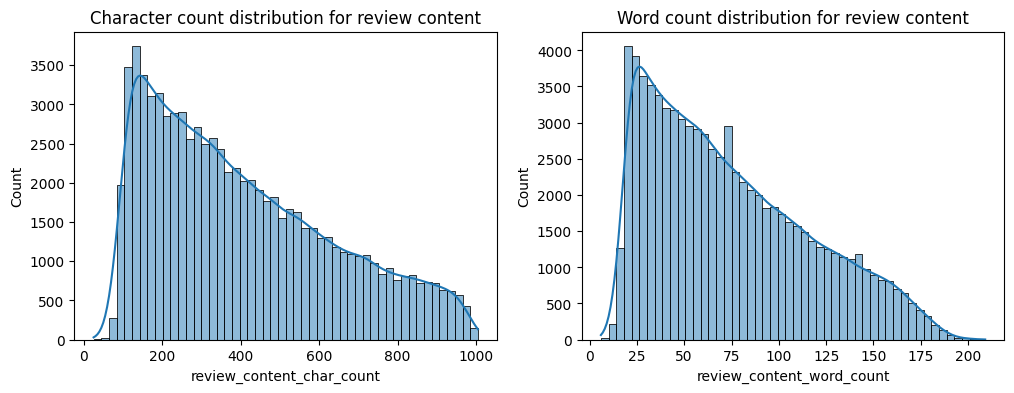

In [21]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(balanced_sample_train['review_content_char_count'], bins=50, kde=True)
plt.title('Character count distribution for review content')
plt.subplot(1,2,2)
sns.histplot(balanced_sample_train['review_content_word_count'], bins=50, kde=True)
plt.title('Word count distribution for review content')
plt.show()

## Text Length Distributions

Both character and word count distributions are right-skewed, with most reviews being relatively short (under 500 characters, 100 words). The long tail of longer reviews suggests some customers provide very detailed feedback, which could be valuable for understanding nuanced sentiments.

top unigrams, bigrams, and trigrams

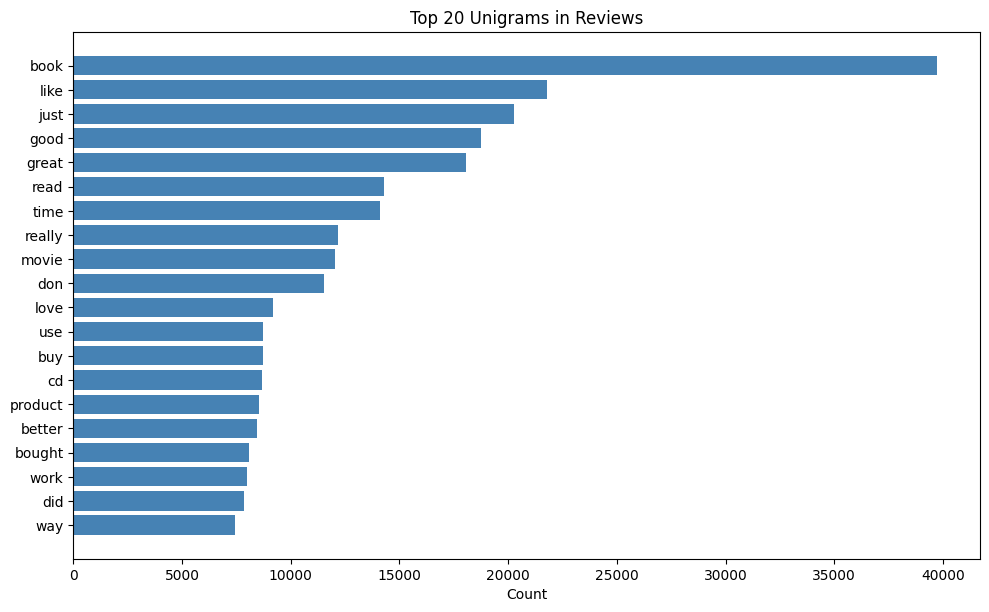

Top 20 Unigrams: [('book', np.int64(39719)), ('like', np.int64(21795)), ('just', np.int64(20285)), ('good', np.int64(18740)), ('great', np.int64(18062)), ('read', np.int64(14299)), ('time', np.int64(14103)), ('really', np.int64(12189)), ('movie', np.int64(12015)), ('don', np.int64(11520)), ('love', np.int64(9177)), ('use', np.int64(8714)), ('buy', np.int64(8713)), ('cd', np.int64(8679)), ('product', np.int64(8550)), ('better', np.int64(8430)), ('bought', np.int64(8095)), ('work', np.int64(7978)), ('did', np.int64(7837)), ('way', np.int64(7431))]


In [22]:
top_unigrams = plot_top_ngrams(balanced_sample_train['review_content'], n=1, top_k=20, stop_words='english', title='Top 20 Unigrams in Reviews')
print("Top 20 Unigrams:", top_unigrams)

## Top Unigrams Analysis

The most frequent words in reviews include common terms like "great", "good", "product", and "like". These unigrams provide a baseline understanding of the vocabulary used in Amazon reviews and can help identify potential stopwords or key sentiment indicators.

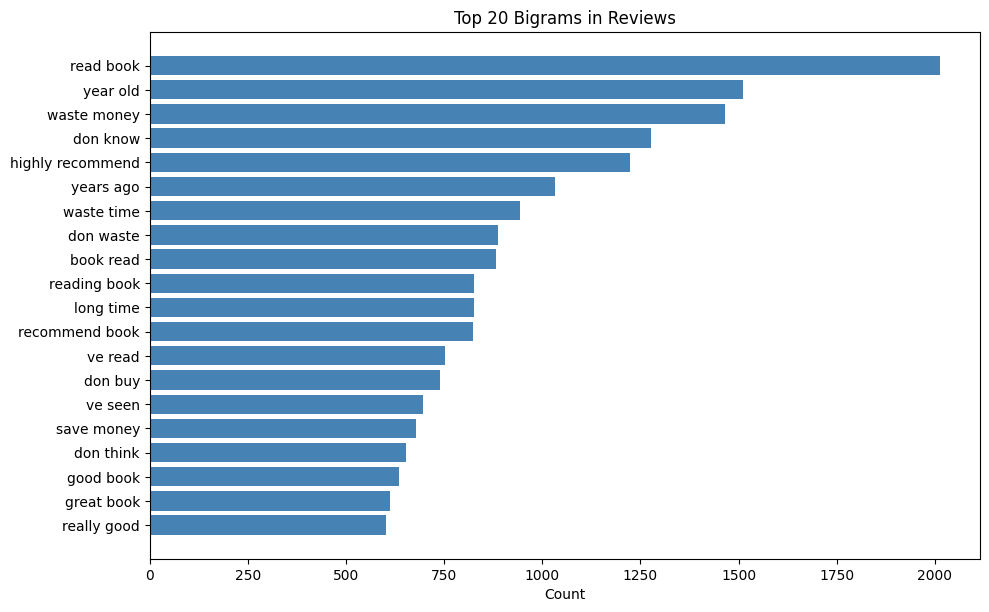

Top 20 Bigrams: [('read book', np.int64(2014)), ('year old', np.int64(1511)), ('waste money', np.int64(1466)), ('don know', np.int64(1277)), ('highly recommend', np.int64(1222)), ('years ago', np.int64(1032)), ('waste time', np.int64(943)), ('don waste', np.int64(887)), ('book read', np.int64(882)), ('reading book', np.int64(826)), ('long time', np.int64(825)), ('recommend book', np.int64(823)), ('ve read', np.int64(752)), ('don buy', np.int64(740)), ('ve seen', np.int64(697)), ('save money', np.int64(678)), ('don think', np.int64(653)), ('good book', np.int64(636)), ('great book', np.int64(611)), ('really good', np.int64(601))]


In [23]:
top_bigrams = plot_top_ngrams(balanced_sample_train['review_content'], n=2, top_k=20, stop_words='english', title='Top 20 Bigrams in Reviews')
print("Top 20 Bigrams:", top_bigrams)

## Top Bigrams Analysis

Bigrams like "great product", "reccomned book", reveal common positive phrases, while "waste money" and "don't buy" indicate negative sentiments. These word pairs provide more context than single words and can improve feature engineering for sentiment analysis.

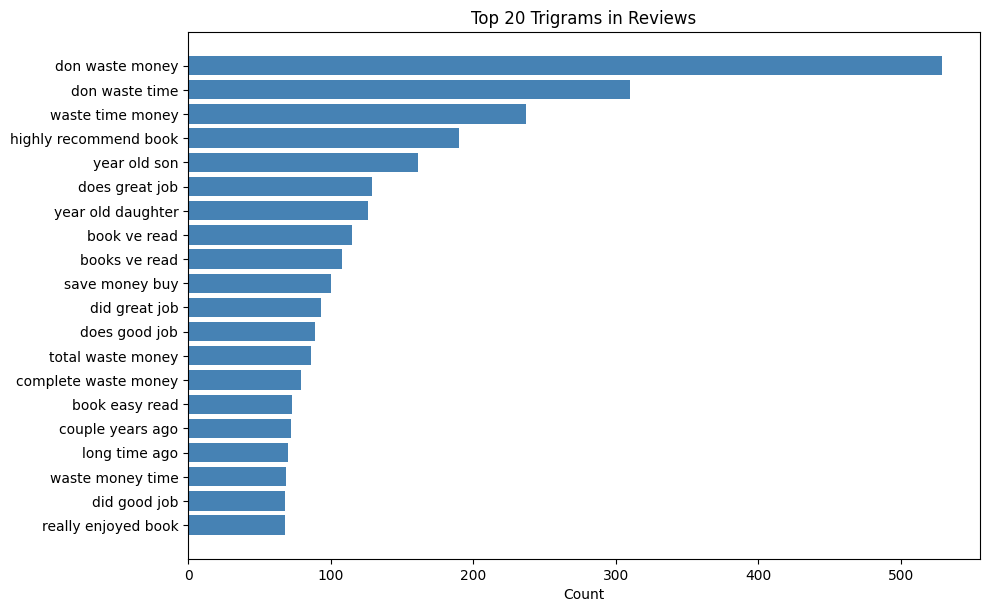

Top 20 Trigrams: [('don waste money', np.int64(529)), ('don waste time', np.int64(310)), ('waste time money', np.int64(237)), ('highly recommend book', np.int64(190)), ('year old son', np.int64(161)), ('does great job', np.int64(129)), ('year old daughter', np.int64(126)), ('book ve read', np.int64(115)), ('books ve read', np.int64(108)), ('save money buy', np.int64(100)), ('did great job', np.int64(93)), ('does good job', np.int64(89)), ('total waste money', np.int64(86)), ('complete waste money', np.int64(79)), ('book easy read', np.int64(73)), ('couple years ago', np.int64(72)), ('long time ago', np.int64(70)), ('waste money time', np.int64(69)), ('did good job', np.int64(68)), ('really enjoyed book', np.int64(68))]


In [24]:
top_trigrams = plot_top_ngrams(balanced_sample_train['review_content'], n=3, top_k=20, stop_words='english', title='Top 20 Trigrams in Reviews')
print("Top 20 Trigrams:", top_trigrams)

## Top Trigrams Analysis

Trigrams such as "does great job" and "highly recommend book" show longer positive expressions, while "waste time money" indicates strong negative sentiment. These three-word combinations capture more nuanced opinions and can be particularly useful for identifying specific sentiment patterns in customer reviews.

save balanced_sample_train dataset

In [25]:
save(df_base='data/processed', df=balanced_sample_train, df_name='balanced_sample_train.csv')

Saved dataframe balanced_sample_train.csv to data\processed\balanced_sample_train.csv


{'csv': WindowsPath('data/processed/balanced_sample_train.csv')}